# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 3-Qubit Error Correction Codes

3-Qubit Error Correction Analysis

Target State: $0.8|0\rangle + 0.6|1\rangle$ | Error Injected on: Qubit 1

1. Circuit Visualisation

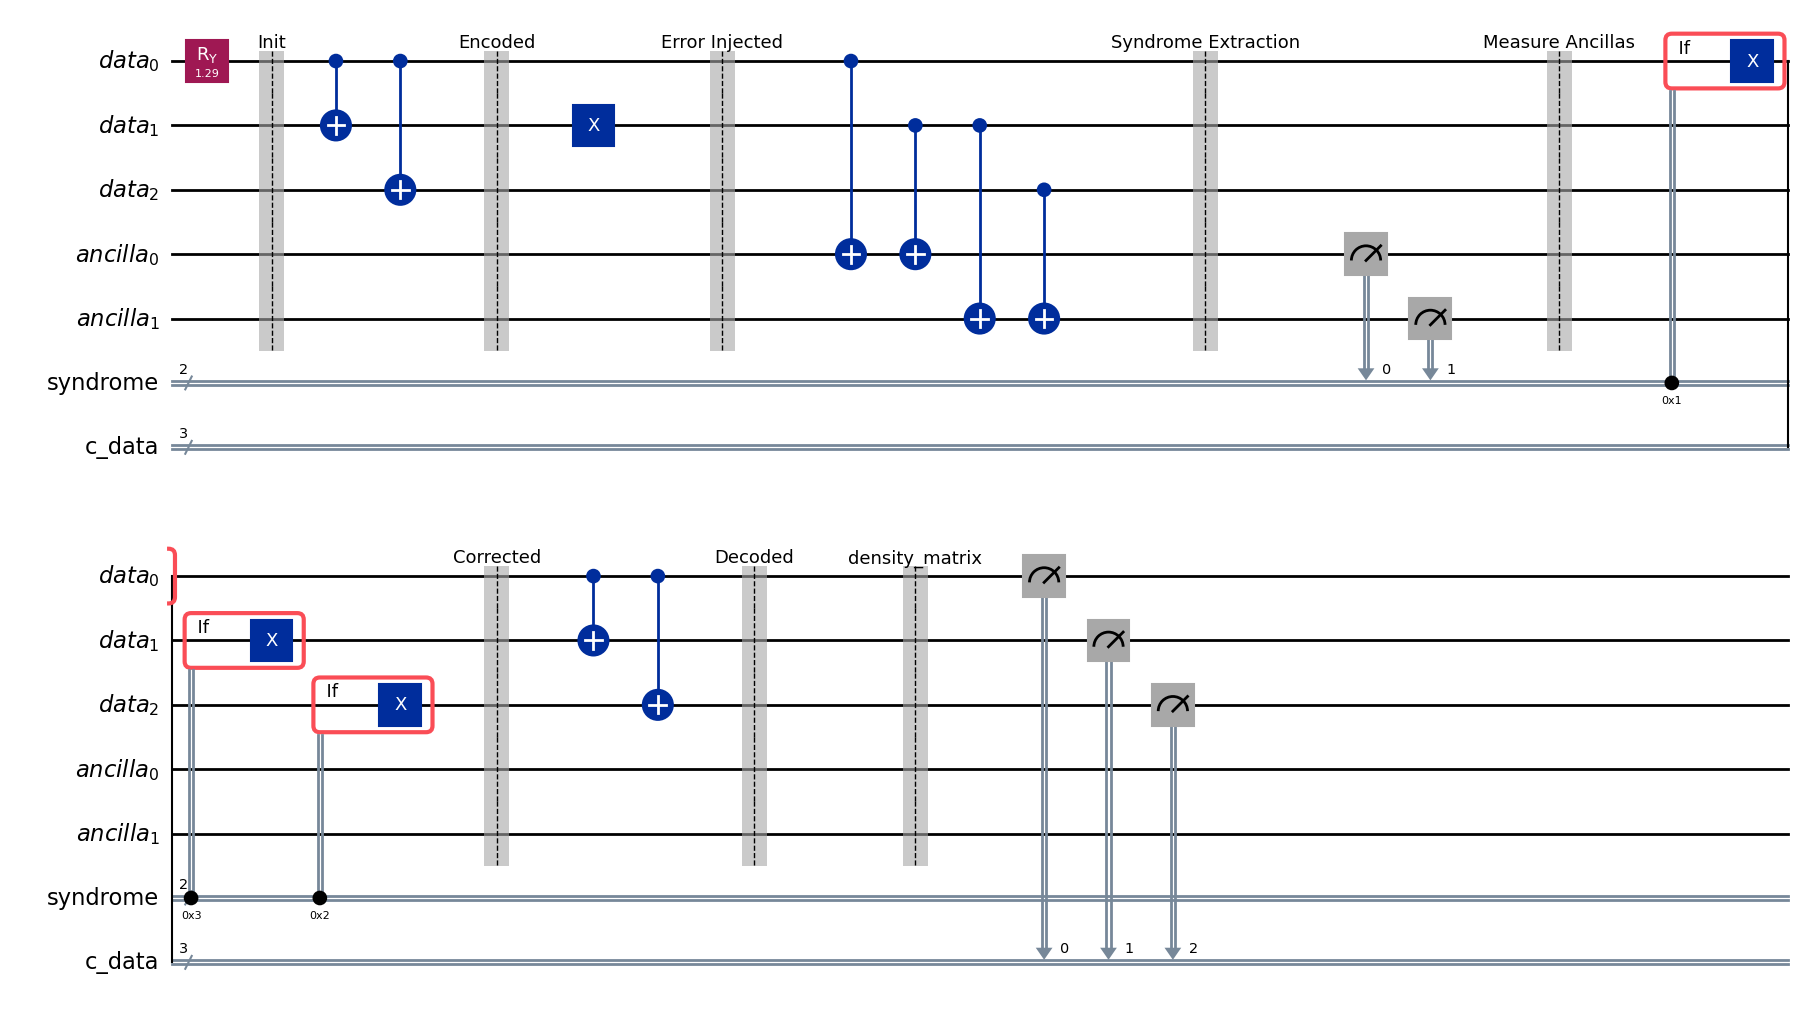

2. Quantum State Representation

Initial target Statevector (Qubit 0):


<IPython.core.display.Latex object>


Final restored DensityMatrix (Qubit 0):


<IPython.core.display.Latex object>

3. State Visualisation

Initial target state (Bloch Sphere):


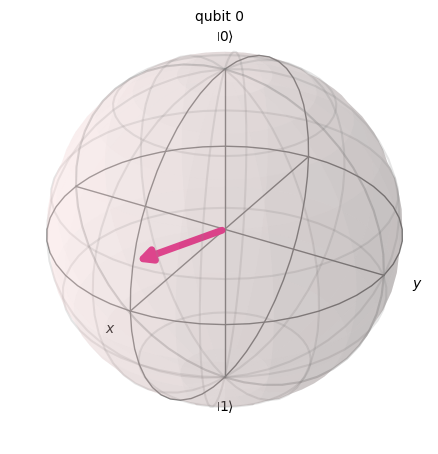


Final restored state (Bloch Sphere):


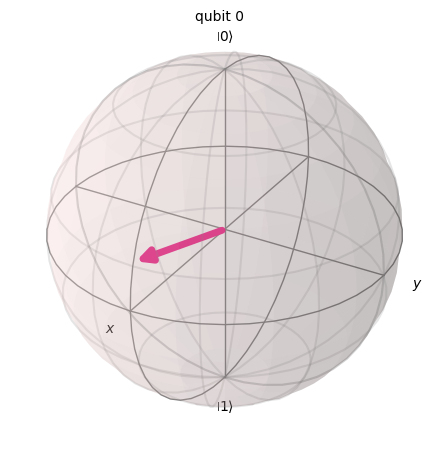


Final restored state (Q-Sphere):


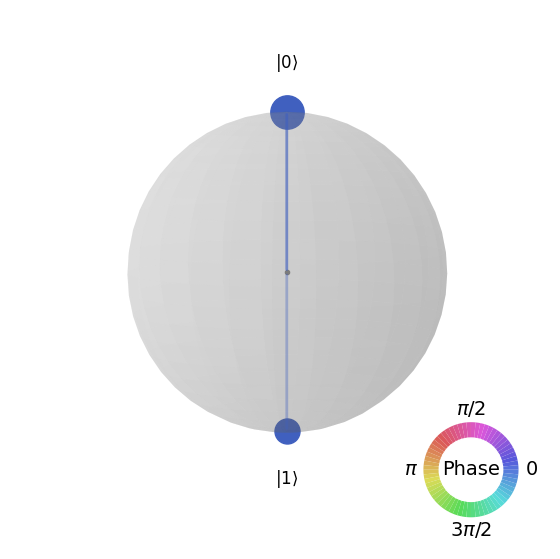

4. Measurement Analysis

Raw measurement counts (c_data syndrome): {'001 11': 359, '000 11': 665}


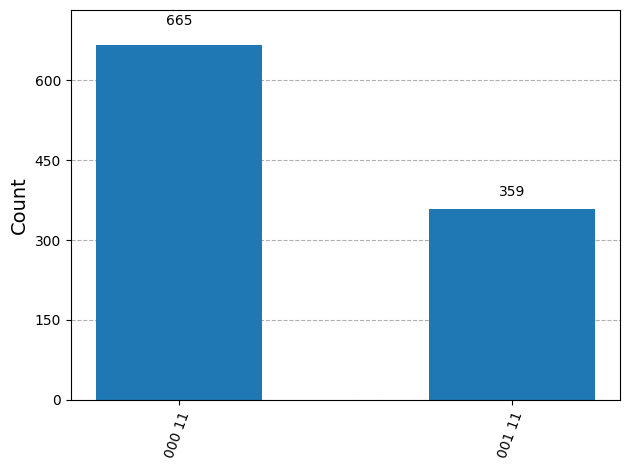

5. Verification: State Fidelity

Restoration Fidelity = 1.000000
Success: The state was perfectly restored despite the injected error.


In [66]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
error_qubit = 1         # Qubit to inject the bit-flip error (0, 1, or 2). Set to None for no error.
alpha, beta = 0.8, 0.6  # Initial state amplitudes

# Calculate rotation angle to prepare the arbitrary state
theta = 2 * np.arccos(alpha)

# 1. Set up Registers & Circuit
qr_data = QuantumRegister(3, name="data")
qr_ancilla = QuantumRegister(2, name="ancilla")
cr_syndrome = ClassicalRegister(2, name="syndrome")
cr_data = ClassicalRegister(3, name="c_data")
qc = QuantumCircuit(qr_data, qr_ancilla, cr_syndrome, cr_data)

# 2. Initialisation
qc.ry(theta, qr_data[0])
qc.barrier(label="Init")

# Save exact initial state of Qubit 0 for fidelity check later
ref_circ = QuantumCircuit(1)
ref_circ.ry(theta, 0)
initial_state = Statevector(ref_circ)

# 3. Encoding (Map a|0> + b|1> to a|000> + b|111>)
qc.cx(qr_data[0], qr_data[1])
qc.cx(qr_data[0], qr_data[2])
qc.barrier(label="Encoded")

# 4. Error Injection
if error_qubit is not None:
    qc.x(qr_data[error_qubit])
qc.barrier(label="Error Injected")

# 5. Syndrome Extraction via Ancillas
# Ancilla 0 measures parity of Data 0 and Data 1
qc.cx(qr_data[0], qr_ancilla[0])
qc.cx(qr_data[1], qr_ancilla[0])
# Ancilla 1 measures parity of Data 1 and Data 2
qc.cx(qr_data[1], qr_ancilla[1])
qc.cx(qr_data[2], qr_ancilla[1])
qc.barrier(label="Syndrome Extraction")

# Measure ancillas to classical syndrome register
qc.measure(qr_ancilla[0], cr_syndrome[0])
qc.measure(qr_ancilla[1], cr_syndrome[1])
qc.barrier(label="Measure Ancillas")

# 6. Dynamic Correction Logic
# Qiskit registers are little-endian (cr[1] cr[0])
# 01 (Dec 1): Parity 01 failed -> Error on Q0
with qc.if_test((cr_syndrome, 1)):
    qc.x(qr_data[0])
# 11 (Dec 3): Both parities failed -> Error on Q1
with qc.if_test((cr_syndrome, 3)):
    qc.x(qr_data[1])
# 10 (Dec 2): Parity 12 failed -> Error on Q2
with qc.if_test((cr_syndrome, 2)):
    qc.x(qr_data[2])
qc.barrier(label="Corrected")

# 7. Decoding (Isolate state back to Q0 for verification)
qc.cx(qr_data[0], qr_data[1])
qc.cx(qr_data[0], qr_data[2])
qc.barrier(label="Decoded")

# ==========================================
# EXTRACT EXACT MATH BEFORE FINAL MEASUREMENT
# ==========================================
# Save density matrix of the full 5-qubit system
qc.save_density_matrix()

# 8. Final Measurement of Data Qubits
qc.measure(qr_data, cr_data)

# 9. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"3-Qubit Error Correction Analysis"))
display(Markdown(f"Target State: ${alpha}|0\\rangle + {beta}|1\\rangle$ | Error Injected on: Qubit {error_qubit}"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Quantum State Representation"))
# Trace out Qubits 1, 2, and both ancillas (indices 1, 2, 3, 4) to isolate Qubit 0
rho_full = result.data()['density_matrix']
rho_q0 = partial_trace(rho_full, [1, 2, 3, 4])

print("Initial target Statevector (Qubit 0):")
display(initial_state.draw('latex'))
print("\nFinal restored DensityMatrix (Qubit 0):")
display(rho_q0.draw('latex'))

display(Markdown("3. State Visualisation"))
print("Initial target state (Bloch Sphere):")
display(plot_bloch_multivector(initial_state))

print("\nFinal restored state (Bloch Sphere):")
display(plot_bloch_multivector(rho_q0))

print("\nFinal restored state (Q-Sphere):")
display(plot_state_qsphere(rho_q0))

display(Markdown("4. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts (c_data syndrome): {counts}")
display(plot_histogram(counts))

# 5. Verification Logic
display(Markdown("5. Verification: State Fidelity"))
fidelity = state_fidelity(initial_state, rho_q0)
print(f"Restoration Fidelity = {fidelity:.6f}")

if np.isclose(fidelity, 1.0):
    print("Success: The state was perfectly restored despite the injected error.")
else:
    print("Warning: Fidelity is less than 1. Error correction failed.")